In [33]:
!pip install mlflow -q

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [34]:
import mlflow
import os

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [35]:
# In MLflow, an Experiment is a container used to organize related machine-learning runs.
mlflow.set_experiment("Loan_Status_Experiment")

# Loan_Status_Experiment
# │
# ├── Run 1 → Logistic Regression
# │     ├── C = 1.0
# │     ├── Accuracy = 0.82
# │     └── model
# │
# ├── Run 2 → Random Forest
# │     ├── n_estimators = 100
# │     ├── Accuracy = 0.87
# │     └── model
# │
# └── Run 3 → XGBoost
#       ├── max_depth = 5
#       ├── Accuracy = 0.89
#       └── model


# The experiment groups all these related attempts together.
# MLflow looks for an experiment with that name.
# If it already exists, MLflow selects it.
# If it doesn't exist, MLflow generally creates it and then selects it.
# After that, new runs are associated with that experiment.

<Experiment: artifact_location=('file:d:/MLOPS_Shivam_prasad/MLOPS_Github_Code/v1-aiml-mlops-sep-2026/lec5 '
 'Experiment Tracking with MLFlow 1/mlruns/1'), creation_time=1790963153487, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790963153487, lifecycle_stage='active', name='Loan_Status_Experiment', tags={}, trace_location=None, workspace='default'>

In [36]:
train_df = pd.read_csv('data/demo_data.csv')
train_df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [37]:
train_df.Loan_Status.value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [38]:
# let's binary encode, Gender, Married Loan_Status

train_df['Gender'] = train_df['Gender'].map({'Male': 0, 'Female': 1})
train_df['Married'] = train_df['Married'].map({'No': 0, 'Yes': 1})
train_df['Loan_Status'] = train_df['Loan_Status'].map({'N': 0, 'Y': 1})

In [39]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    float64
 2   Married            611 non-null    float64
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    int64  
dtypes: float64(6), int64(2), str(5)
memory usage: 78.5 KB


In [40]:
train_df = train_df.dropna()

# Let's Create Features

In [41]:


feature_columns = ['Gender', 'Married', 'ApplicantIncome', 'LoanAmount', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History']
X = train_df[feature_columns]
y = train_df.Loan_Status

In [42]:
# mlflow.log_param() is used to store a parameter for the current MLflow run.
# Its basic syntax is:
# mlflow.log_param("parameter_name", parameter_value)

# In short: mlflow.log_param("feature_columns", feature_columns) saves the list of input features used in that particular MLflow run, 
# making the experiment easier to reproduce and compare later.
# Loan_Status_Experiment

# Run 1
#  ├── feature_columns = [Income, LoanAmount]
#  └── accuracy = 0.78

# Run 2
#  ├── feature_columns = [Income, LoanAmount, Credit_History]
#  └── accuracy = 0.85

# Run 3
#  ├── feature_columns = [Income, LoanAmount, Credit_History, Education]
#  └── accuracy = 0.87
# Later, when you open the MLflow UI, you can determine exactly which features were used for each run.
# This is particularly useful when you're experimenting with feature selection.


mlflow.log_param("feature_columns", feature_columns)


['Gender',
 'Married',
 'ApplicantIncome',
 'LoanAmount',
 'CoapplicantIncome',
 'Loan_Amount_Term',
 'Credit_History']

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=5)

In [44]:
# depth = 10
# criteria = 'gini'
# n_esti = 10


# depth = 5
# criteria = 'gini'
# n_esti = 100

depth = 5
criteria = 'entropy'
n_esti = 1000

mlflow.log_param("max_depth", depth)
mlflow.log_param("criterion", criteria)
mlflow.log_param("n_estimators", n_esti)

# mlflow.log_param({
#     "max_depth": depth,
#     "criterion": criteria,
#     "n_estimators": n_esti
# })


model = RandomForestClassifier(max_depth=depth, random_state=5, criterion=criteria, n_estimators=n_esti)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [45]:
from sklearn.metrics import accuracy_score

pred_val = model.predict(X_val)
val_acc_score = accuracy_score(y_val, pred_val)

print(f"Training Accuracy: {model.score(X_train, y_train)}, Validation Accuracy: {val_acc_score}")


Training Accuracy: 0.8463541666666666, Validation Accuracy: 0.7916666666666666


In [46]:
mlflow.log_metric("train_accuracy", model.score(X_train, y_train)) # records how the model performed.
mlflow.log_metric("val_accuracy", val_acc_score)
# feature_columns  → PARAMETER → What did I use?
# train_accuracy   → METRIC    → How did it perform on training data?
# val_accuracy     → METRIC    → How did it perform on unseen validation data?


In [47]:
mlflow.end_run()

In [17]:

print(mlflow.get_tracking_uri())

sqlite:///d:/MLOPS_Shivam_prasad/MLOPS_Github_Code/v1-aiml-mlops-sep-2026/lec5%20Experiment%20Tracking%20with%20MLFlow%201/mlflow.db


# Test for Eyes

In [ ]:
def mlflow_runs(n_est,max_dep,i):
    with mlflow.start_run():

        model_rf = RandomForestClassifier(n_estimators=n_est, max_depth=max_dep, random_state=5)
        model_rf.fit(X_train, y_train)

        # Validation accuracy
        pred_val = model_rf.predict(X_val)
        val_acc=accuracy_score(y_val, pred_val)

        # Training accuracy
        pred_train = model_rf.predict(X_train)
        train_acc=accuracy_score(y_train, pred_train)

        # Run name 
        run="hyperparameter_run_"+str(i)
        mlflow.set_tag('mlflow.runName',run)
        
        # Parameters
        mlflow.log_param('n_estimators',n_est)
        mlflow.log_param('max_depth',max_dep)
        mlflow.log_param('model_name','RandomForestClassifier')


        # Metrics
        mlflow.log_metric('val_acc',val_acc)
        mlflow.log_metric('train_acc',train_acc)
        
        # Tag. this tag can be anything
        mlflow.set_tag('data file','data_new.csv') # This adds a tag (metadata) to the current MLflow run.

        # Save my trained scikit-learn model model_rf as an artifact of the current MLflow run.
        # mlflow.sklearn.log_model(model_rf, "model")
        # model_rf : This is the actual trained Python model you want to save.
        # "model" : This identifies the model artifact within the MLflow run.
        # Log trained model
        mlflow.sklearn.log_model(
    model_rf,
    "model",
    skops_trusted_types=[
        "sklearn.tree._tree.Tree"
    ]
)

mlflow_runs(10,2,1)
mlflow_runs(20,2,2)
mlflow_runs(40,2,3)
mlflow_runs(10,4,4)
mlflow_runs(20,4,5)
mlflow_runs(40,4,6)
mlflow_runs(10,8,7)
mlflow_runs(20,8,8)
mlflow_runs(40,8,9)

2026/10/02 23:42:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/02 23:43:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/02 23:43:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/02 23:43:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/02 23:43:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/02 23:43:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/02 23:43:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/02 23:43:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/02 23:43:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/10/03 00:10:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/03 00:10:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


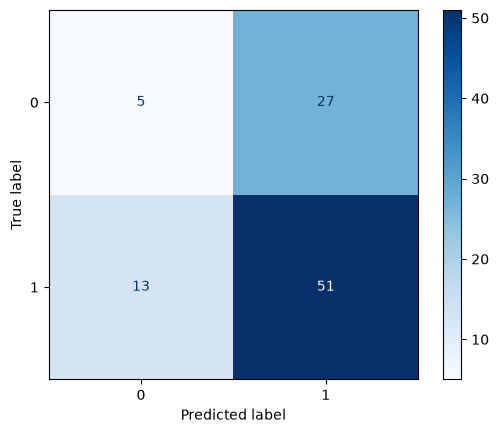

In [55]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import joblib #	Saves Python/scikit-learn models to files


with mlflow.start_run():
	knn_model= KNeighborsClassifier(n_neighbors=5)
	knn_model.fit(X_train, y_train)

	pred_val = knn_model.predict(X_val)
	val_acc=accuracy_score(y_val, pred_val)

	pred_train = knn_model.predict(X_train)
	train_acc=accuracy_score(y_train, pred_train)

	run="KNN"
	mlflow.set_tag('mlflow.runName',run)
	mlflow.log_param('neighbors',5)
	mlflow.log_metric('val_acc',val_acc)
	mlflow.log_metric('train_acc',train_acc)
	mlflow.log_param('model_name','KNeighborsClassifier')

	cm=ConfusionMatrixDisplay.from_predictions( y_val,pred_val, cmap='Blues')
	cm.figure_.savefig('confusion_mat.png')
	mlflow.log_artifact('confusion_mat.png') # log_artifact can be used to log any file, of any format, e.g. images, text files, etc, with max-size of 5 GB. 

	# save dataframe as artifact

	mlflow.log_artifact('data/demo_data.csv')

	mlflow.sklearn.log_model(knn_model, "model_knn", serialization_format="cloudpickle")
 # serialization_format="cloudpickle" tells MLflow how to serialize the underlying Python/scikit-learn object.
	joblib.dump(knn_model, 'knn_model.joblib') # This is a standalone serialized Python model file.
	mlflow.log_artifact('knn_model.joblib') # Now the standalone Joblib file is also stored as an MLflow artifact.
 
 
 
#  Accuracy gives you one number: But it doesn't tell you what kinds of mistakes the model made.
#  The confusion matrix helps you understand the model's errors much better than accuracy alone.